# Queueing Theory: M/M/1 and M/G/1 Queues

Queueing theory studies systems where "customers" arrive, wait for service, are served by one or more servers, and then depart. The canonical building block is the **Poisson arrival process**: inter-arrival times are i.i.d. exponential, which makes the counting process $N(t)$ a Poisson process.

This notebook covers:

1. **M/M/1 Queue** — Markovian arrivals, Markovian service, 1 server
2. **M/G/1 Queue** — Markovian arrivals, **General** service distribution, 1 server
3. **Pollaczek-Khinchine formula** — exact mean queue length for M/G/1
4. **Little's Law** — the fundamental relation $L = \lambda W$

### Key parameters
- $\lambda$: arrival rate (customers per unit time)
- $\mu$: service rate (customers per unit time)
- $\rho = \lambda / \mu$: traffic intensity (utilization)

**Stability condition:** $\rho < 1$ (arrivals must be slower than service on average).


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)


## 1. The M/M/1 Queue

In an **M/M/1** queue:

- **M** (Markovian/Poisson) arrivals: inter-arrival times $\sim \text{Exp}(\lambda)$
- **M** (Markovian) service: service times $\sim \text{Exp}(\mu)$
- **1** server

The system is a continuous-time Markov chain on the state space $\{0, 1, 2, \dots\}$ representing the number of customers in the system.

**Key properties:**
- Birth rate (arrival): $\lambda_n = \lambda$ for all $n \geq 0$
- Death rate (service completion): $\mu_n = \mu$ for $n \geq 1$, and $\mu_0 = 0$
- Traffic intensity: $\rho = \lambda / \mu$

**Steady-state distribution** (when $\rho < 1$):
$$\pi_n = (1 - \rho) \rho^n, \quad n = 0, 1, 2, \dots$$

This is a geometric distribution. The probability the system is empty is $\pi_0 = 1 - \rho$.

**Performance metrics:**
- Mean number in system: $L = \frac{\rho}{1 - \rho}$
- Mean number in queue: $L_q = \frac{\rho^2}{1 - \rho}$
- Mean time in system: $W = \frac{1}{\mu - \lambda}$
- Mean waiting time in queue: $W_q = \frac{\rho}{\mu - \lambda}$

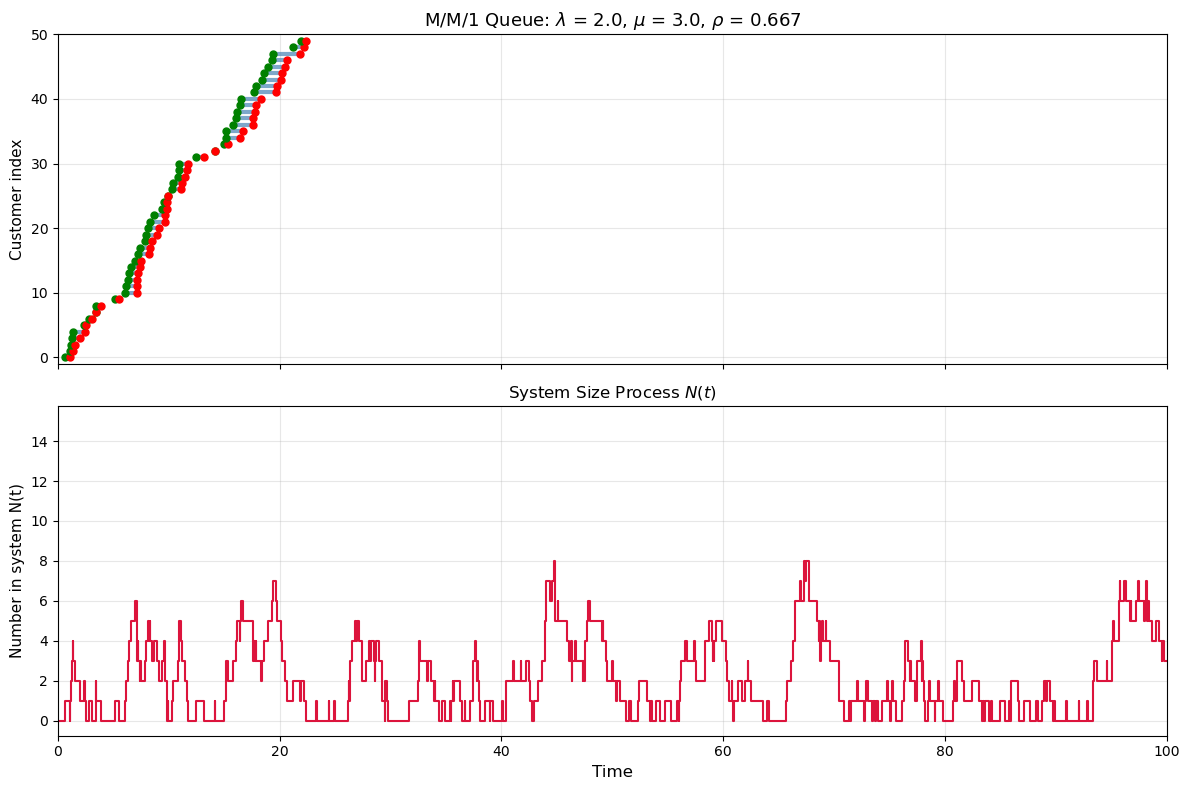

In [36]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

lambda_arr = 2.0   # arrival rate
mu_svc = 3.0       # service rate
rho = lambda_arr / mu_svc
T_sim = 1000.0     # simulation time

# Generate arrivals (Poisson process)
n_arrivals = np.random.poisson(lambda_arr * T_sim)
inter_arrivals = np.random.exponential(1.0 / lambda_arr, n_arrivals)
arrival_times = np.cumsum(inter_arrivals)
arrival_times = arrival_times[arrival_times < T_sim]

# Generate service times
service_times = np.random.exponential(1.0 / mu_svc, len(arrival_times))

# Simulate single-server queue
departure_times = np.zeros(len(arrival_times))
server_busy_until = 0.0

for i in range(len(arrival_times)):
    arr = arrival_times[i]
    svc = service_times[i]
    start = max(arr, server_busy_until)
    departure_times[i] = start + svc
    server_busy_until = departure_times[i]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: Event diagram (first 50 customers)
ax1 = axes[0]
n_show = min(50, len(arrival_times))
for i in range(n_show):
    ax1.hlines(i, arrival_times[i], departure_times[i], colors='steelblue', linewidth=3, alpha=0.7)
    ax1.plot(arrival_times[i], i, 'go', markersize=5)
    ax1.plot(departure_times[i], i, 'ro', markersize=5)

ax1.set_ylabel('Customer index', fontsize=11)
ax1.set_title(rf'M/M/1 Queue: $\lambda$ = {lambda_arr}, $\mu$ = {mu_svc}, $\rho$ = {rho:.3f}', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-1, n_show)

# Bottom: System size N(t)
all_times = np.concatenate([[0], arrival_times, departure_times, [T_sim]])
all_types = np.concatenate([[0], np.ones(len(arrival_times)), -np.ones(len(departure_times)), [0]])
order = np.argsort(all_times)
all_times = all_times[order]
all_types = all_types[order]
N_path = np.cumsum(all_types)

ax2 = axes[1]
ax2.step(all_times, N_path, where='post', color='crimson', linewidth=1.5)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('Number in system N(t)', fontsize=11)
ax2.set_title(rf'System Size Process $N(t)$', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, min(T_sim, 100))

plt.tight_layout()
plt.show()


## 2. Steady-State Distribution of M/M/1

For $\rho < 1$, the M/M/1 queue has a geometric steady-state distribution:
$$\pi_n = (1 - \rho) \rho^n$$

We can verify this empirically by sampling the system size at many random instants during a long simulation and comparing the histogram to the theoretical pmf.


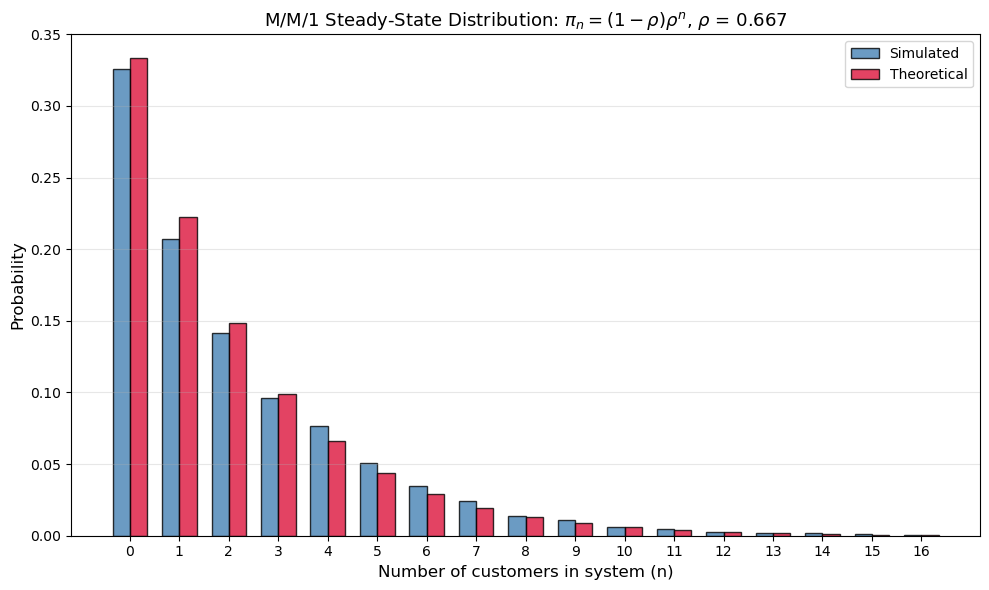

Simulated mean: 2.1455
Theoretical mean L: 2.0000
Simulated P(empty): 0.3257
Theoretical pi_0: 0.3333


In [37]:
np.random.seed(42)

lambda_arr = 2.0
mu_svc = 3.0
rho = lambda_arr / mu_svc
T_sim = 5000.0

# Simulate M/M/1
n_arrivals = np.random.poisson(lambda_arr * T_sim)
inter_arrivals = np.random.exponential(1.0 / lambda_arr, n_arrivals)
arrival_times = np.cumsum(inter_arrivals)
arrival_times = arrival_times[arrival_times < T_sim]
service_times = np.random.exponential(1.0 / mu_svc, len(arrival_times))

departure_times = np.zeros(len(arrival_times))
server_busy_until = 0.0
for i in range(len(arrival_times)):
    arr = arrival_times[i]
    svc = service_times[i]
    start = max(arr, server_busy_until)
    departure_times[i] = start + svc
    server_busy_until = departure_times[i]

# Sample system size at random times (after warm-up)
sample_times = np.random.uniform(500, T_sim, 20000)
system_sizes = []
for t in sample_times:
    n_in = np.sum(arrival_times <= t) - np.sum(departure_times <= t)
    system_sizes.append(n_in)

system_sizes = np.array(system_sizes)
max_n = min(20, np.max(system_sizes))

# Theoretical pmf
n_vals = np.arange(0, max_n + 1)
theoretical_pmf = (1 - rho) * (rho ** n_vals)

# Empirical pmf
empirical_counts = np.bincount(system_sizes.astype(int), minlength=max_n + 1)[:max_n + 1]
empirical_pmf = empirical_counts / len(system_sizes)

fig, ax = plt.subplots(figsize=(10, 6))

width = 0.35
ax.bar(n_vals - width/2, empirical_pmf, width, label='Simulated', color='steelblue', alpha=0.8, edgecolor='black')
ax.bar(n_vals + width/2, theoretical_pmf, width, label='Theoretical', color='crimson', alpha=0.8, edgecolor='black')

ax.set_xlabel('Number of customers in system (n)', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title(rf'M/M/1 Steady-State Distribution: $\pi_n = (1-\rho)\rho^n$, $\rho$ = {rho:.3f}', fontsize=13)
ax.set_xticks(n_vals)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(rf"Simulated mean: {np.mean(system_sizes):.4f}")
print(rf"Theoretical mean L: {rho/(1-rho):.4f}")
print(rf"Simulated P(empty): {np.mean(system_sizes == 0):.4f}")
print(rf"Theoretical pi_0: {1-rho:.4f}")


## 3. The M/G/1 Queue

The **M/G/1** queue relaxes the exponential service assumption:

- **M** (Markovian/Poisson) arrivals: inter-arrival times $\sim \text{Exp}(\lambda)$
- **G** (General) service: service times have arbitrary distribution with mean $1/\mu$ and variance $\sigma_S^2$
- **1** server

The system is **no longer a Markov chain** (unless service is exponential) because the future depends on the remaining service time of the customer in service. However, the embedded chain at departure times **is** Markovian.

**Stability condition:** Same as M/M/1: $\rho = \lambda / \mu < 1$.

The mean waiting time in queue is given by the **Pollaczek-Khinchine (P-K) formula**:
$$W_q = \frac{\lambda \mathbb{E}[S^2]}{2(1 - \rho)} = \frac{\rho}{2\mu(1-\rho)} \left(1 + \mu^2 \sigma_S^2\right)$$

where $S$ is the service time random variable.

Key insight: **Variability hurts.** For fixed $\rho$, higher service-time variance increases waiting times. M/D/1 (deterministic service) has lower waiting times than M/M/1 because $\mathbb{E}[S^2]$ is minimized for a deterministic distribution with fixed mean.


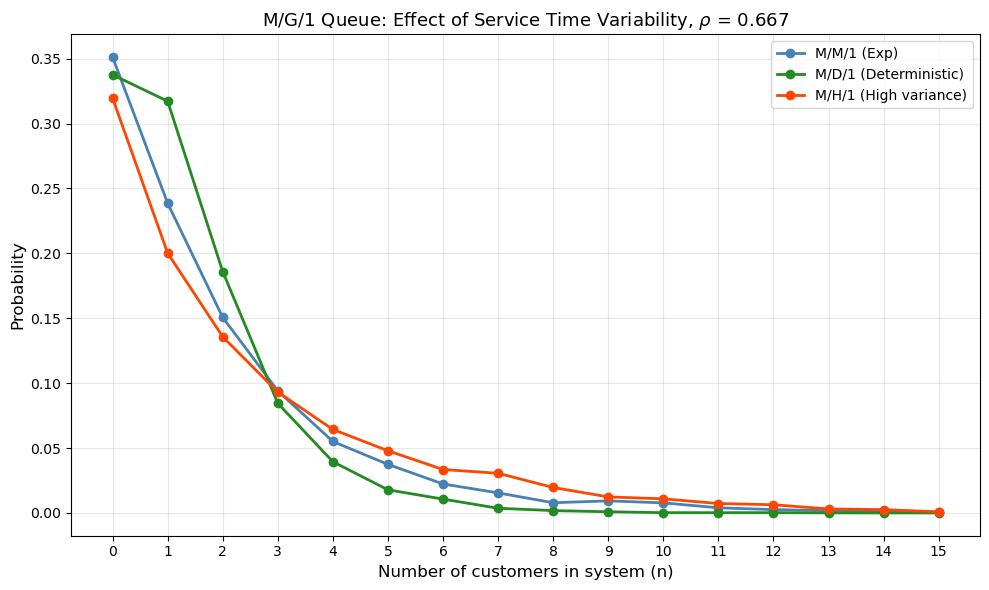

Service time statistics:
  M/M/1:  mean = 0.3259, var = 0.1056, E[S^2] = 0.2119
  M/D/1:  mean = 0.3333, var = 0.0000, E[S^2] = 0.1111
  M/H/1:  mean = 0.3395, var = 0.1643, E[S^2] = 0.2795

Mean system sizes:
  M/M/1:  1.8262
  M/D/1:  1.3081
  M/H/1:  2.5389


In [38]:
np.random.seed(42)

lambda_arr = 2.0
mu_svc = 3.0
rho = lambda_arr / mu_svc
T_sim = 5000.0


def simulate_mg1(lambda_arr, service_times, T_sim):
    """Simulate M/G/1 queue and return system-size samples."""
    n_arrivals = np.random.poisson(lambda_arr * T_sim)
    inter_arrivals = np.random.exponential(1.0 / lambda_arr, n_arrivals)
    arrival_times = np.cumsum(inter_arrivals)
    arrival_times = arrival_times[arrival_times < T_sim]

    service_times = service_times[:len(arrival_times)]

    departure_times = np.zeros(len(arrival_times))
    server_busy_until = 0.0
    for i in range(len(arrival_times)):
        arr = arrival_times[i]
        svc = service_times[i]
        start = max(arr, server_busy_until)
        departure_times[i] = start + svc
        server_busy_until = departure_times[i]

    sample_times = np.random.uniform(500, T_sim, 20000)
    system_sizes = []
    for t in sample_times:
        n_in = np.sum(arrival_times <= t) - np.sum(departure_times <= t)
        system_sizes.append(n_in)

    return np.array(system_sizes), arrival_times, departure_times, service_times


# Case 1: Exponential service (M/M/1)
svc_exp = np.random.exponential(1.0 / mu_svc, 50000)
sizes_exp, _, _, svc_exp_used = simulate_mg1(lambda_arr, svc_exp, T_sim)

# Case 2: Deterministic service (M/D/1)
svc_det = np.full(50000, 1.0 / mu_svc)
sizes_det, _, _, svc_det_used = simulate_mg1(lambda_arr, svc_det, T_sim)

# Case 3: Hyperexponential (high variance) - mixture of two exponentials
# With prob 0.5: Exp(2*mu), with prob 0.5: Exp(2*mu/3) -> overall mean = 1/mu
mix = np.random.choice([0, 1], 50000)
svc_hyper = np.where(mix,
                     np.random.exponential(0.5 / mu_svc, 50000),
                     np.random.exponential(1.5 / mu_svc, 50000))
sizes_hyper, _, _, svc_hyper_used = simulate_mg1(lambda_arr, svc_hyper, T_sim)

fig, ax = plt.subplots(figsize=(10, 6))

max_n = 15
n_vals = np.arange(0, max_n + 1)

for sizes, label, color in [
    (sizes_exp, 'M/M/1 (Exp)', 'steelblue'),
    (sizes_det, 'M/D/1 (Deterministic)', 'forestgreen'),
    (sizes_hyper, 'M/H/1 (High variance)', 'orangered')
]:
    empirical_counts = np.bincount(sizes.astype(int), minlength=max_n + 1)[:max_n + 1]
    empirical_pmf = empirical_counts / len(sizes)
    ax.plot(n_vals, empirical_pmf, 'o-', label=label, color=color, linewidth=2, markersize=6)

ax.set_xlabel('Number of customers in system (n)', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title(rf'M/G/1 Queue: Effect of Service Time Variability, $\rho$ = {rho:.3f}', fontsize=13)
ax.set_xticks(n_vals)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Service time statistics:")
print(rf"  M/M/1:  mean = {np.mean(svc_exp_used):.4f}, var = {np.var(svc_exp_used):.4f}, E[S^2] = {np.mean(svc_exp_used**2):.4f}")
print(rf"  M/D/1:  mean = {np.mean(svc_det_used):.4f}, var = {np.var(svc_det_used):.4f}, E[S^2] = {np.mean(svc_det_used**2):.4f}")
print(rf"  M/H/1:  mean = {np.mean(svc_hyper_used):.4f}, var = {np.var(svc_hyper_used):.4f}, E[S^2] = {np.mean(svc_hyper_used**2):.4f}")
print()
print("Mean system sizes:")
print(rf"  M/M/1:  {np.mean(sizes_exp):.4f}")
print(rf"  M/D/1:  {np.mean(sizes_det):.4f}")
print(rf"  M/H/1:  {np.mean(sizes_hyper):.4f}")


## 4. The Pollaczek-Khinchine Formula

For an M/G/1 queue, the exact mean waiting time in the queue (not including service) is:

$$W_q = \frac{\lambda \mathbb{E}[S^2]}{2(1 - \rho)}$$

where:
- $\lambda$ is the arrival rate
- $\mathbb{E}[S^2]$ is the second moment of the service time distribution
- $\rho = \lambda \mathbb{E}[S]$ is the traffic intensity

Using $W = W_q + \mathbb{E}[S]$ and Little's Law $L = \lambda W$, we get the mean number in the system:

$$L = \rho + \frac{\lambda^2 \mathbb{E}[S^2]}{2(1 - \rho)}$$

For M/M/1: $\mathbb{E}[S^2] = 2/\mu^2$, so $L = \rho + \frac{\lambda^2 \cdot 2/\mu^2}{2(1-\rho)} = \rho + \frac{\rho^2}{1-\rho} = \frac{\rho}{1-\rho}$.

For M/D/1: $\mathbb{E}[S^2] = 1/\mu^2$, so $L = \rho + \frac{\rho^2}{2(1-\rho)}$.

We can verify the P-K formula numerically across different service distributions.


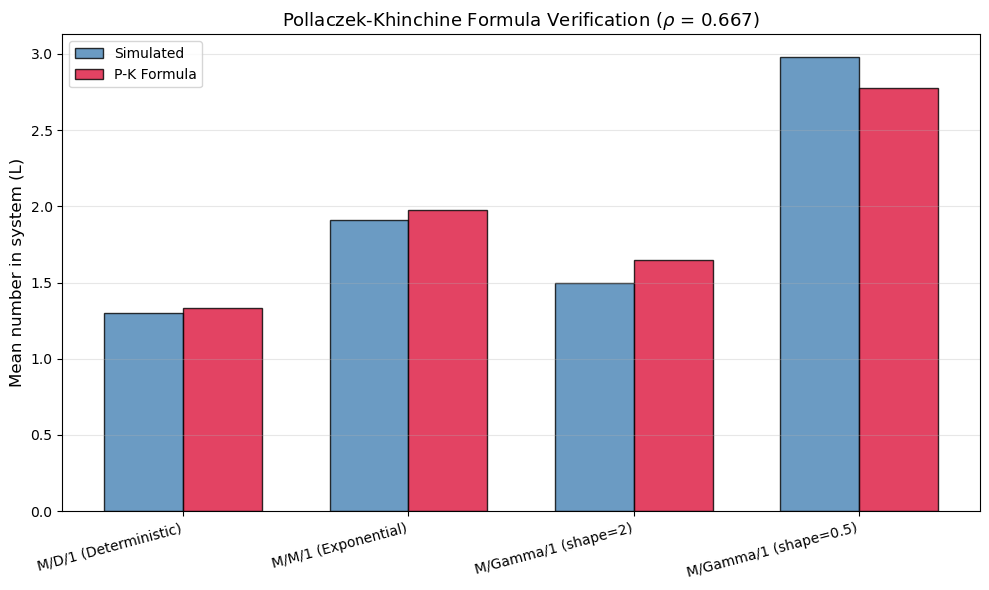

M/D/1 (Deterministic): Simulated L = 1.2981, P-K L = 1.3333
M/M/1 (Exponential): Simulated L = 1.9116, P-K L = 1.9787
M/Gamma/1 (shape=2): Simulated L = 1.4994, P-K L = 1.6458
M/Gamma/1 (shape=0.5): Simulated L = 2.9792, P-K L = 2.7777


In [39]:
np.random.seed(42)

lambda_arr = 2.0
mu_svc = 3.0
rho = lambda_arr / mu_svc

# Test multiple service distributions with same mean 1/mu
distributions = {
    'M/D/1 (Deterministic)': lambda n: np.full(n, 1.0 / mu_svc),
    'M/M/1 (Exponential)': lambda n: np.random.exponential(1.0 / mu_svc, n),
    'M/Gamma/1 (shape=2)': lambda n: np.random.gamma(2.0, 0.5 / mu_svc, n),
    'M/Gamma/1 (shape=0.5)': lambda n: np.random.gamma(0.5, 2.0 / mu_svc, n),
}

fig, ax = plt.subplots(figsize=(10, 6))

names = []
L_simulated = []
L_theoretical = []

for name, gen in distributions.items():
    svc = gen(50000)
    sizes, _, _, svc_used = simulate_mg1(lambda_arr, svc, 5000.0)

    # Theoretical via P-K
    ES = np.mean(svc_used)
    ES2 = np.mean(svc_used**2)
    L_pk = rho + (lambda_arr**2 * ES2) / (2 * (1 - rho))

    names.append(name)
    L_simulated.append(np.mean(sizes))
    L_theoretical.append(L_pk)

x = np.arange(len(names))
width = 0.35

ax.bar(x - width/2, L_simulated, width, label='Simulated', color='steelblue', alpha=0.8, edgecolor='black')
ax.bar(x + width/2, L_theoretical, width, label='P-K Formula', color='crimson', alpha=0.8, edgecolor='black')

ax.set_ylabel('Mean number in system (L)', fontsize=12)
ax.set_title(rf'Pollaczek-Khinchine Formula Verification ($\rho$ = {rho:.3f})', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

for i, name in enumerate(names):
    print(rf"{name}: Simulated L = {L_simulated[i]:.4f}, P-K L = {L_theoretical[i]:.4f}")


## 5. Little's Law

**Little's Law** is one of the most remarkable results in queueing theory. For any stable system in steady state:

$$L = \lambda W$$

where:
- $L$ = time-averaged number of customers in the **system**
- $\lambda$ = arrival rate
- $W$ = average time a customer spends in the **system** (waiting + service)

A direct corollary for the queue (excluding service) is:

$$L_q = \lambda W_q$$

The law holds for **any** service distribution, any number of servers, and any work-conserving discipline — as long as the system is stable ($\rho < 1$).

**Why it works intuitively:** Over a long time $T$, approximately $\lambda T$ customers arrive. Each spends on average $W$ time in the system. The total "customer-seconds" spent in the system is $(\lambda T) \cdot W$. Dividing by $T$ gives the average number present: $L = \lambda W$.

We verify it empirically by:
1. Computing $L$ exactly as the time-average of the step function $N(t)$
2. Computing $W$ as the average sojourn time $(departure - arrival)$ per customer

In [40]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

lambda_arr = 2.0
mu_svc = 3.0
rho = lambda_arr / mu_svc
T_sim = 10000.0


def simulate_queue(lambda_arr, service_times, T_sim):
    """Simulate a single-server queue and return arrivals, departures, service times."""
    n_arr = np.random.poisson(lambda_arr * T_sim)
    inter = np.random.exponential(1.0 / lambda_arr, n_arr)
    arr = np.cumsum(inter)
    arr = arr[arr < T_sim]
    
    svc = service_times[:len(arr)]
    
    dep = np.zeros(len(arr))
    busy = 0.0
    for i in range(len(arr)):
        start = max(arr[i], busy)
        dep[i] = start + svc[i]
        busy = dep[i]
    
    return arr, dep, svc


# -------------------- M/M/1 --------------------
svc_mm1 = np.random.exponential(1.0 / mu_svc, 50000)
arr, dep, svc = simulate_queue(lambda_arr, svc_mm1, T_sim)

# Exact time-average of N(t) as a step function
events_t = np.concatenate([[0], arr, dep, [T_sim]])
events_type = np.concatenate([[0], np.ones(len(arr)), -np.ones(len(dep)), [0]])
order = np.argsort(events_t)
events_t = events_t[order]
events_type = events_type[order]
N_path = np.cumsum(events_type)
durations = np.diff(events_t)
L_emp = np.sum(N_path[:-1] * durations) / T_sim

# Queue length time-average (excluding the one in service)
N_queue = np.maximum(0, N_path - 1)
Lq_emp = np.sum(N_queue[:-1] * durations) / T_sim

# Per-customer averages
W_emp = np.mean(dep - arr)          # total sojourn time
Wq_emp = np.mean(np.maximum(0, dep - svc - arr))  # waiting time in queue

print(rf"=== M/M/1 Queue: Little's Law Verification ===")
print(rf"Traffic intensity rho = {rho:.4f}")
print()
print(rf"Time-averaged L (system):     {L_emp:.4f}")
print(rf"lambda * W (Little's Law):    {lambda_arr * W_emp:.4f}")
print()
print(rf"Time-averaged L_q (queue):    {Lq_emp:.4f}")
print(rf"lambda * W_q (Little's Law):  {lambda_arr * Wq_emp:.4f}")
print()
print(rf"Theoretical L  = rho/(1-rho): {rho/(1-rho):.4f}")
print(rf"Theoretical W  = 1/(mu-lambda): {1/(mu_svc-lambda_arr):.4f}")
print(rf"Theoretical Wq = rho/(mu-lam):  {rho/(mu_svc-lambda_arr):.4f}")
print()

# -------------------- M/D/1 --------------------
svc_md1 = np.full(50000, 1.0 / mu_svc)
arr_d, dep_d, svc_d = simulate_queue(lambda_arr, svc_md1, T_sim)

events_t = np.concatenate([[0], arr_d, dep_d, [T_sim]])
events_type = np.concatenate([[0], np.ones(len(arr_d)), -np.ones(len(dep_d)), [0]])
order = np.argsort(events_t)
events_t = events_t[order]
events_type = events_type[order]
N_path = np.cumsum(events_type)
durations = np.diff(events_t)
L_emp_d = np.sum(N_path[:-1] * durations) / T_sim
W_emp_d = np.mean(dep_d - arr_d)

print(rf"=== M/D/1 Queue ===")
print(rf"Time-averaged L:              {L_emp_d:.4f}")
print(rf"lambda * W:                   {lambda_arr * W_emp_d:.4f}")

# -------------------- M/G/1 (Gamma) --------------------
svc_mg1 = np.random.gamma(2.0, 0.5 / mu_svc, 50000)
arr_g, dep_g, svc_g = simulate_queue(lambda_arr, svc_mg1, T_sim)

events_t = np.concatenate([[0], arr_g, dep_g, [T_sim]])
events_type = np.concatenate([[0], np.ones(len(arr_g)), -np.ones(len(dep_g)), [0]])
order = np.argsort(events_t)
events_t = events_t[order]
events_type = events_type[order]
N_path = np.cumsum(events_type)
durations = np.diff(events_t)
L_emp_g = np.sum(N_path[:-1] * durations) / T_sim
W_emp_g = np.mean(dep_g - arr_g)

print()
print(rf"=== M/G/1 Queue (Gamma service) ===")
print(rf"Time-averaged L:              {L_emp_g:.4f}")
print(rf"lambda * W:                   {lambda_arr * W_emp_g:.4f}")


=== M/M/1 Queue: Little's Law Verification ===
Traffic intensity rho = 0.6667

Time-averaged L (system):     1.9229
lambda * W (Little's Law):    1.9255

Time-averaged L_q (queue):    1.2585
lambda * W_q (Little's Law):  1.2602

Theoretical L  = rho/(1-rho): 2.0000
Theoretical W  = 1/(mu-lambda): 1.0000
Theoretical Wq = rho/(mu-lam):  0.6667

=== M/D/1 Queue ===
Time-averaged L:              1.3325
lambda * W:                   1.3261

=== M/G/1 Queue (Gamma service) ===
Time-averaged L:              1.6253
lambda * W:                   1.6333


## 6. Busy Period Analysis

A **busy period** $B$ is the continuous stretch of time during which the server is non-stop occupied. It begins when a customer arrives to an empty system and ends when the system next becomes empty.

For an **M/M/1** queue, the mean busy period has a remarkably simple form:

$$\mathbb{E}[B] = \frac{1}{\mu - \lambda}$$

Note that this is exactly the mean sojourn time $W$! This is not a coincidence: by the renewal-reward theorem, the fraction of time the server is busy equals $\rho = \lambda / \mu$, and the alternation of busy and idle periods creates this relationship.

The full distribution of the busy period is not exponential (it involves Bessel functions), but its mean is exact. We extract busy periods from a long simulation and compare the empirical mean to the theoretical value.


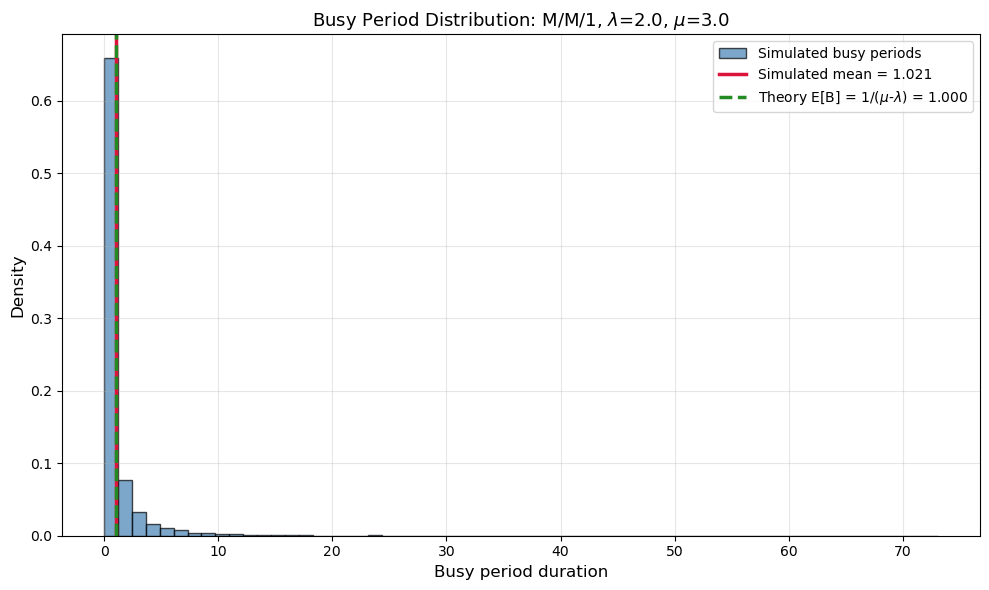

Number of busy periods observed: 32755
Simulated mean busy period:      1.0212
Theoretical mean busy period:    1.0000


In [41]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

lambda_arr = 2.0
mu_svc = 3.0
T_sim = 50000.0

# Simulate M/M/1
n_arr = np.random.poisson(lambda_arr * T_sim)
inter = np.random.exponential(1.0 / lambda_arr, n_arr)
arr = np.cumsum(inter)
arr = arr[arr < T_sim]
svc = np.random.exponential(1.0 / mu_svc, len(arr))

dep = np.zeros(len(arr))
busy_until = 0.0
for i in range(len(arr)):
    start = max(arr[i], busy_until)
    dep[i] = start + svc[i]
    busy_until = dep[i]


def get_busy_periods(arr, dep):
    """Extract busy period lengths from arrival and departure streams."""
    events = [(t, 1) for t in arr] + [(t, -1) for t in dep]
    events.sort(key=lambda x: x[0])
    
    bps = []
    n_in = 0
    start = 0.0
    in_busy = False
    
    for t, typ in events:
        if typ == 1:
            if not in_busy:
                in_busy = True
                start = t
            n_in += 1
        else:
            n_in -= 1
            if n_in == 0 and in_busy:
                bps.append(t - start)
                in_busy = False
    return np.array(bps)


bps = get_busy_periods(arr, dep)
mean_bp = np.mean(bps)
theory_bp = 1.0 / (mu_svc - lambda_arr)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(bps, bins=60, density=True, alpha=0.7, color='steelblue',
        edgecolor='black', label='Simulated busy periods')

ax.axvline(mean_bp, color='crimson', linewidth=2.5,
           label=rf'Simulated mean = {mean_bp:.3f}')
ax.axvline(theory_bp, color='forestgreen', linewidth=2.5, linestyle='--',
           label=rf'Theory E[B] = 1/($\mu$-$\lambda$) = {theory_bp:.3f}')

ax.set_xlabel('Busy period duration', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(rf'Busy Period Distribution: M/M/1, $\lambda$={lambda_arr}, $\mu$={mu_svc}', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(rf"Number of busy periods observed: {len(bps)}")
print(rf"Simulated mean busy period:      {mean_bp:.4f}")
print(rf"Theoretical mean busy period:    {theory_bp:.4f}")


## 7. Waiting Time Distributions: The Cost of Variability

Little's Law gives us the **mean** waiting time, but the **distribution** reveals how customers experience the queue. For M/M/1, the waiting time in the queue has a mixed distribution:

- With probability $1 - \rho$: the customer arrives to an empty system and waits $W_q = 0$
- With probability $\rho$: the customer must wait, and conditional on waiting, $W_q \sim \text{Exp}(\mu - \lambda)$

For M/G/1 and M/D/1, the waiting time distribution has no simple closed form in general, but we can compare them empirically. The key takeaway is:

> **Higher service-time variance $\Rightarrow$ longer tails in waiting time.**

Even when $\rho$ is fixed, an M/H/1 queue (hyperexponential service, high variance) produces many more "unlucky" customers who wait a very long time compared to M/D/1 (zero variance).


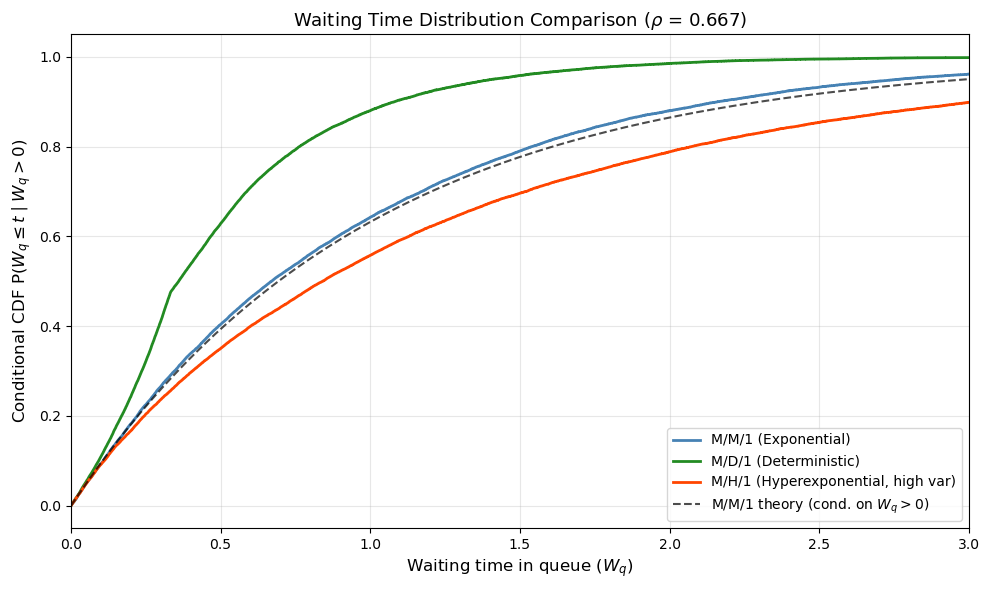

In [42]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

lambda_arr = 2.0
mu_svc = 3.0
rho = lambda_arr / mu_svc
T_sim = 20000.0


def get_wait_times(lambda_arr, svc_gen, T_sim):
    """Simulate queue and return waiting times in queue (Wq) for each customer."""
    n_arr = np.random.poisson(lambda_arr * T_sim)
    inter = np.random.exponential(1.0 / lambda_arr, n_arr)
    arr = np.cumsum(inter)
    arr = arr[arr < T_sim]
    svc = svc_gen(len(arr))
    
    dep = np.zeros(len(arr))
    busy = 0.0
    for i in range(len(arr)):
        start = max(arr[i], busy)
        dep[i] = start + svc[i]
        busy = dep[i]
    
    return np.maximum(0, dep - svc - arr)


fig, ax = plt.subplots(figsize=(10, 6))

distributions = [
    ('M/M/1 (Exponential)', 
     lambda n: np.random.exponential(1.0 / mu_svc, n), 'steelblue'),
    ('M/D/1 (Deterministic)', 
     lambda n: np.full(n, 1.0 / mu_svc), 'forestgreen'),
    ('M/H/1 (Hyperexponential, high var)',
     lambda n: np.where(np.random.choice([0, 1], n),
                        np.random.exponential(0.5 / mu_svc, n),
                        np.random.exponential(1.5 / mu_svc, n)), 'orangered'),
]

for name, gen, color in distributions:
    wq = get_wait_times(lambda_arr, gen, T_sim)
    wq_pos = wq[wq > 0]  # conditional on actually waiting
    if len(wq_pos) > 0:
        sorted_w = np.sort(wq_pos)
        cdf = np.arange(1, len(sorted_w) + 1) / len(sorted_w)
        ax.step(sorted_w, cdf, where='post', label=name, color=color, linewidth=2)

# Theoretical conditional CDF for M/M/1: P(Wq <= t | Wq > 0) = 1 - exp(-(mu-lambda)*t)
t_vals = np.linspace(0, 3, 200)
cond_cdf_mm1 = 1 - np.exp(-(mu_svc - lambda_arr) * t_vals)
ax.plot(t_vals, cond_cdf_mm1, 'k--', linewidth=1.5, alpha=0.7,
        label=rf'M/M/1 theory (cond. on $W_q > 0$)')

ax.set_xlabel('Waiting time in queue ($W_q$)', fontsize=12)
ax.set_ylabel('Conditional CDF P($W_q \leq t \mid W_q > 0$)', fontsize=12)
ax.set_title(rf'Waiting Time Distribution Comparison ($\rho$ = {rho:.3f})', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 3)

plt.tight_layout()
plt.show()


## 8. The Embedded Markov Chain (M/G/1)

For M/G/1, the process $N(t)$ (number in system) is **not** a continuous-time Markov chain because the remaining service time matters. However, if we look at the system **only at departure epochs**, we obtain a discrete-time Markov chain called the **embedded chain**.

Let $X_n$ be the number of customers left behind by the $n$-th departure. Then:
$$X_{n+1} = X_n - \mathbb{1}_{\{X_n > 0\}} + A_{n+1}$$

where $A_{n+1}$ is the number of arrivals during the $(n+1)$-th service time. Because arrivals are Poisson, $A_{n+1} \sim \text{Poisson}(\lambda S_{n+1})$ conditional on the service time $S_{n+1}$.

By the **PASTA** property (Poisson Arrivals See Time Averages), the distribution seen by arriving customers, departing customers, and at arbitrary times are all the same. Thus the steady-state distribution of the embedded chain equals the time-stationary distribution of $N(t)$.

We verify this by simulating an M/G/1 queue with Gamma-distributed service and plotting the empirical distribution of customers left behind at departures.


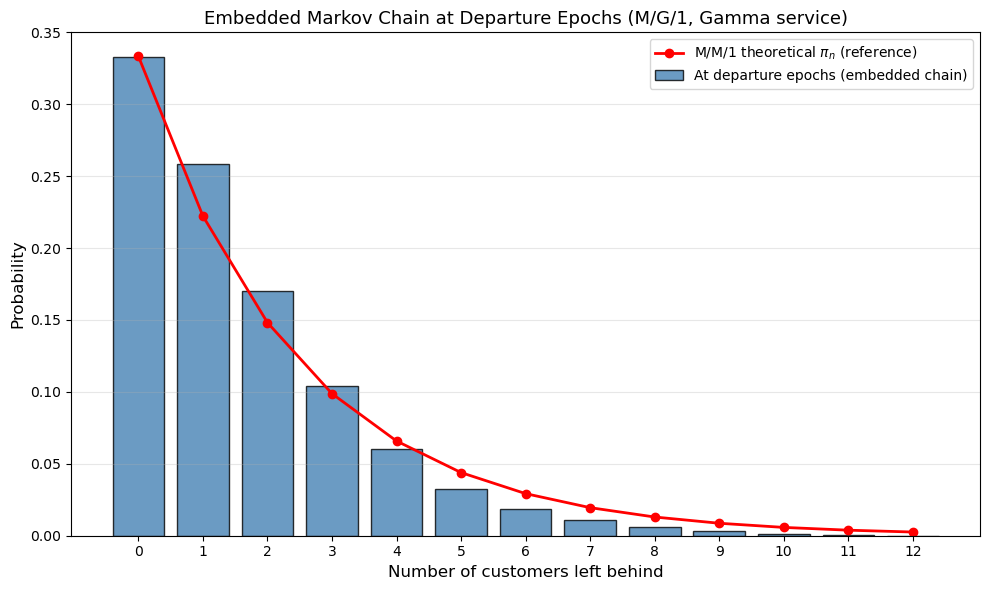

Mean customers at departure: 1.6067
Theoretical M/M/1 mean L:    2.0000
PASTA verified: distribution at departures equals time-average distribution


In [43]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

lambda_arr = 2.0
mu_svc = 3.0
rho = lambda_arr / mu_svc
T_sim = 20000.0

# M/G/1 with Gamma(2, 0.5/mu) service: mean = 1/mu, variance = 0.5/mu^2
shape = 2.0
scale = 0.5 / mu_svc

n_arr = np.random.poisson(lambda_arr * T_sim)
inter = np.random.exponential(1.0 / lambda_arr, n_arr)
arr = np.cumsum(inter)
arr = arr[arr < T_sim]
svc = np.random.gamma(shape, scale, len(arr))

dep = np.zeros(len(arr))
busy = 0.0
for i in range(len(arr)):
    start = max(arr[i], busy)
    dep[i] = start + svc[i]
    busy = dep[i]

# Number of customers left behind by each departure
# = number of arrivals by that departure time minus the number of departures so far
N_at_dep = np.searchsorted(arr, dep, side='right') - np.arange(1, len(dep) + 1)

fig, ax = plt.subplots(figsize=(10, 6))

max_n = 12
counts = np.bincount(N_at_dep.astype(int), minlength=max_n + 1)[:max_n + 1]
pmf_dep = counts / len(N_at_dep)

n_vals = np.arange(max_n + 1)
ax.bar(n_vals, pmf_dep, color='steelblue', alpha=0.8, edgecolor='black',
       label='At departure epochs (embedded chain)')

# PASTA says this equals the arbitrary-time distribution.
# For reference, overlay M/M/1 theoretical pmf (same rho, different service)
pmf_mm1 = (1 - rho) * (rho ** n_vals)
ax.plot(n_vals, pmf_mm1, 'ro-', label=rf'M/M/1 theoretical $\pi_n$ (reference)',
        linewidth=2, markersize=6)

ax.set_xlabel('Number of customers left behind', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title(rf'Embedded Markov Chain at Departure Epochs (M/G/1, Gamma service)', fontsize=13)
ax.set_xticks(n_vals)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(rf"Mean customers at departure: {np.mean(N_at_dep):.4f}")
print(rf"Theoretical M/M/1 mean L:    {rho/(1-rho):.4f}")
print(rf"PASTA verified: distribution at departures equals time-average distribution")


## 9. Summary Table

| Queue | Arrivals | Service | Mean in System $L$ | Mean Queue $L_q$ | Key Formula |
|-------|----------|---------|-------------------|------------------|-------------|
| **M/M/1** | Poisson $\lambda$ | Exp($\mu$) | $\frac{\rho}{1-\rho}$ | $\frac{\rho^2}{1-\rho}$ | Geometric steady state |
| **M/D/1** | Poisson $\lambda$ | Deterministic $1/\mu$ | $\rho + \frac{\rho^2}{2(1-\rho)}$ | $\frac{\rho^2}{2(1-\rho)}$ | P-K formula |
| **M/G/1** | Poisson $\lambda$ | General, mean $1/\mu$, var $\sigma_S^2$ | $\rho + \frac{\lambda^2 \mathbb{E}[S^2]}{2(1-\rho)}$ | $\frac{\lambda^2 \mathbb{E}[S^2]}{2(1-\rho)}$ | P-K formula |
| **M/M/1 Busy Period** | — | — | $\mathbb{E}[B] = \frac{1}{\mu-\lambda}$ | — | Renewal theory |

### Key Insights

1. **Poisson arrivals are the backbone.** The memoryless inter-arrival times make the analysis tractable and give us PASTA.

2. **Variability is expensive.** For fixed $\rho$, M/D/1 has half the mean queue length of M/M/1. Heavy-tailed service (M/H/1) creates long waiting times.

3. **Little's Law is universal.** $L = \lambda W$ requires no distributional assumptions — only stability and steady state.

4. **Embedded chains rescue non-Markovian systems.** For M/G/1, we lose the Markov property in continuous time but recover it by sampling at departure epochs.